# Time-Series

## 1. Pengumpukan Data

Pertama kita akan mengumpulkan data Time Series Harian kadar NO2 di daerah Bangkalan. Pengumpulan data dari sumber website https://dataspace.copernicus.eu/ , buat akun terlebih dahulu di website copernicus tersebut.

Dokumentasi cara pengambilan data di https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html .

Pertama Install terlebih dahulu openeo

In [1]:
import openeo

ModuleNotFoundError: No module named 'openeo'

Lalu melakukan coneksi dengan kode dibawah

In [60]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


Untuk Mendapatkan data, membutuhkan koordinat dari daerah yang ingin diambil

In [61]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [
              113.18187453039775,
              -7.078754617448951
            ],
            [
              113.2819948,
              -7.0501078
            ],
            [
              113.38832465217507,
              -7.078833326574113
            ],
            [
              113.38853013561737,
              -7.255980660015467
            ],
            [
              113.18184923514411,
              -7.255980660015467
            ],
            [
              113.0871358,
              -7.1127453
            ],
            [
              113.18187453039775,
              -7.078754617448951
            ]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2024-01-01", "2026-06-01"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

Code diatas memerlukan titik koordinasi area yang akan diambil data -nya, untuk mengambil titik koordinasi kaian kunjungi webiste https://geojson.io/?map=14.13/-7.2/113.25#map=14.8/-7.04732/112.69463 . Didalam website tersebut kalian akan memilih daerah dengan cara memberi shape kotak didaerah yang ingin kalian ambil datanya.

![Gambar Peta Koordinat](image/koordinat.png)

Lakukan proses pengambilan data menggunakan code dibawah ini

In [62]:
job = s5post.execute_batch(title="NO2 in Sampang", outputfile="NO2Sampang.nc")

0:00:00 Job 'j-26060308213242c58db05c7de49ff4fe': send 'start'
0:00:11 Job 'j-26060308213242c58db05c7de49ff4fe': queued (progress 0%)
0:00:17 Job 'j-26060308213242c58db05c7de49ff4fe': queued (progress 0%)
0:00:23 Job 'j-26060308213242c58db05c7de49ff4fe': queued (progress 0%)
0:00:32 Job 'j-26060308213242c58db05c7de49ff4fe': queued (progress 0%)
0:00:42 Job 'j-26060308213242c58db05c7de49ff4fe': running (progress N/A)
0:00:55 Job 'j-26060308213242c58db05c7de49ff4fe': running (progress N/A)
0:01:10 Job 'j-26060308213242c58db05c7de49ff4fe': running (progress N/A)
0:01:30 Job 'j-26060308213242c58db05c7de49ff4fe': running (progress N/A)
0:01:54 Job 'j-26060308213242c58db05c7de49ff4fe': running (progress N/A)
0:02:24 Job 'j-26060308213242c58db05c7de49ff4fe': running (progress N/A)
0:03:02 Job 'j-26060308213242c58db05c7de49ff4fe': running (progress N/A)
0:03:49 Job 'j-26060308213242c58db05c7de49ff4fe': running (progress N/A)
0:04:48 Job 'j-26060308213242c58db05c7de49ff4fe': running (progress N

Ketika proses pengambilan data, aktivitas kalian akan terekam di halaman https://openeo.dataspace.copernicus.eu/?discover=0 Disitu terdapat nama dataset dan status pengambilan data.

![Gambar proses ambil data](image/openeo.png)

## 2. Preproccessing Data

Setelah kita mengambil data, data bisa diunduh di halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2 . File akan berbentuk .nc. Kita cuman perlu kolom date dan NO2 menggunakan code dibawah:

In [63]:
import netCDF4

file_path = "data/NO2Sampang_2.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
876
9
8
3.1133957e-05


Contoh 10 data pertama:

In [64]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[3.113395723630674e-05 3.113395723630674e-05 -- -- -- -- -- --]
 [5.017420699005015e-05 5.017420699005015e-05 -- -- -- -- -- --]
 [5.017420699005015e-05 7.44911449146457e-05 -- -- -- -- -- --]
 [7.44911449146457e-05 7.44911449146457e-05 -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [7.092202577041462e-05 4.7315170377260074e-05 4.7315170377260074e-05
  2.249634599138517e-05 2.249634599138517e-05 -- -- --]]
[[-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]
 [-- -- -- -- -- -- -- --]]
[[2.0626572222681716e-05 8.885500392352697e-06 1.8133399862563238e-05
  5.306559387463494e-07 1.3535622201743536e-05 6.373936230374966e-06
  1.816665280784946e-05 1.6458538084407337e-05]
 [-- 3.1526760722044855e-05 1.8133399862563238e-05 9.383

### a. Missing Value

Code ini akan mengisi missing value pada NO2 dengan metode Interpolasi Linear

In [65]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

### b. Rata-rata Data dan Mengubah Datetime

Setelah mengatasi missing value, kita akan me-rata-rata-kan data NO2 agar satu record hanya berupa single value. Sekalian kita mengambil date nya dan menaruh di array. Kita akan mengubah datetime dari awalnya (2023-10-04 00:00:00) menjadi (2023-10-04) karena kita mengambil data time series harian jadi kita tidak memerlukan data jam, menit dan detik.

In [66]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

### c. Menyimpan Dalam Bentuk CSV

Setelah itu kita akan membentuk data menjadi DataFrame Pandas untuk disimpan menjadi CSV.

In [75]:
df = pd.DataFrame({
    "date": dates,
    "NO2": no2_filled.mean(axis=(1, 2))  # rata-rata NO2 per tanggal
})

# Simpan ke CSV
df.to_csv("NO2_Sampang_timeseries.csv", index=False)

### d. Pengecekan Missing Value data harian pada CSV

Sekarang setelah data berbentuk CSV, kita cek apakah data Time Series harian lengkap. Cara men-cek apakah data Time Series Harian lengkap gunakan code dibawah:

In [80]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Sampang_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2024-01-01"
end_date = "2026-06-01"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 7
Daftar tanggal missing:
DatetimeIndex(['2024-01-01', '2024-03-23', '2024-08-12', '2025-01-30',
               '2025-01-31', '2026-02-24', '2026-06-01'],
              dtype='datetime64[ns]', freq=None)


Dalam data saya terdapat 7 missing value. Kita akan mengatasi lagi missing value menggunakan metode Interpolasi Linear. Cara memperbaikinya gunakan code dibawah:

In [81]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2024-01-01", end="2026-06-01", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated.csv")

C:\Users\asus\AppData\Local\Temp\ipykernel_4288\2706884923.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


In [129]:
import pandas as pd
import numpy as np

df = pd.read_csv("no2_timeseries_interpolated.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2024-01-01"
end_date = "2026-06-01"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


Setelah dicek missing value sudah tidak ada lagi missing value

### e. Deteksi Outlier IQR

Setelah kita mengisi missing value menggunakan metode Interpolasi Linear, selanjutnya kita akan mendeteksi Outlier menggunakan metode IQR.

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 2
          date       NO2
262 2024-09-19  0.000077
290 2024-10-17  0.000047


Visualisasi Outlier:

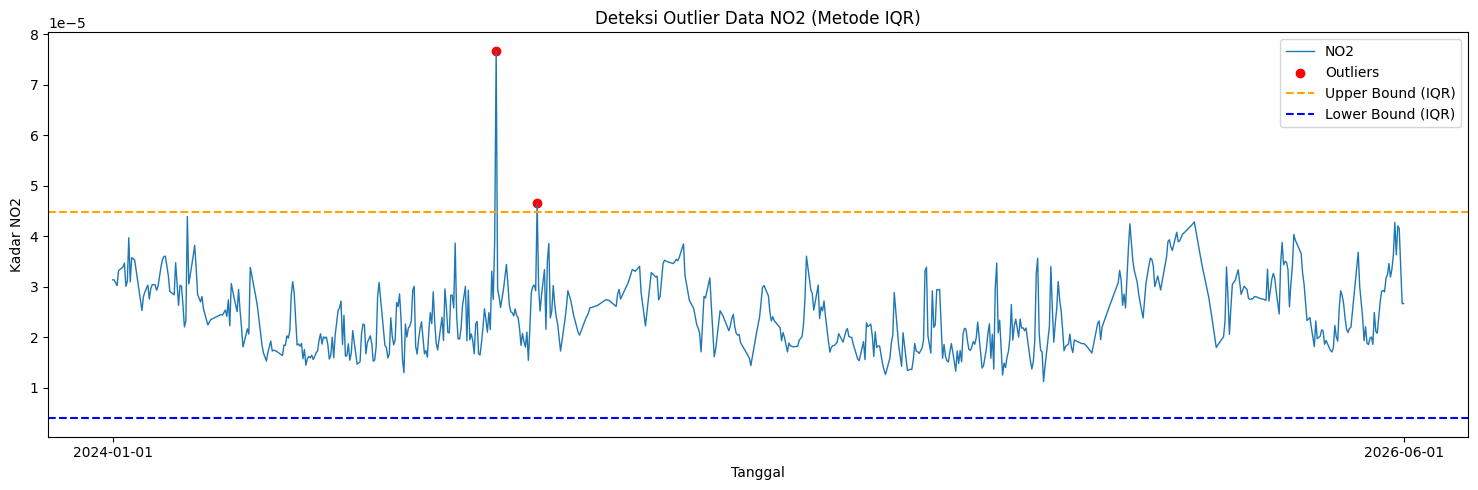

In [131]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], 
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Setelah itu, kita akan menghapus data outlier. Karena data ini merupakan data Time Series, maka data outlier yang dihapus akan diisi kembali menggunakan Interpolasi Linear.

In [132]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 2
Jumlah missing setelah interpolasi: 0


Visualisasi data setelah menghapus Outlier dan mengisi kembali menggunakan Interpolasi Linear:

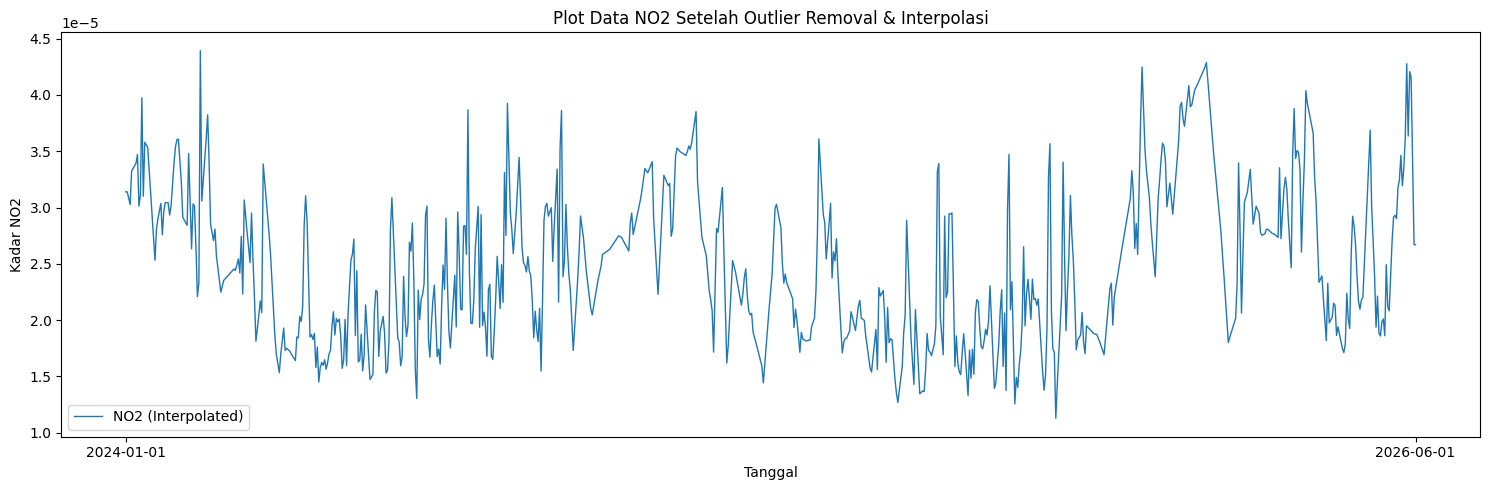

In [133]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Modeling menggunakan KNN Regression

Dengan data Time Series kadar NO2 harian di daerah Bangkalan, kita akan memprediksi kadar NO2 satu hari yang akan datang. Sekarang kita akan ubah data, mencoba mencari korelasi antara 1 hari dengan 4 hari sebelumnya. Kita juga akan membandingkan apakah semakin banyak hari sebelumnya, model akan lebih bagus?

### a. Uji Korelasi Data

Sebelum masuk ke modeling, data kita merupakan data unsupervised yang berarti tidak ada label. Kita ubah data menjadi supervised lalu uji korelasi terhadap label (t). Fitur-fitur nya merupakan 30 hari sebelum (t-30, t-29, … t-1) dan label (t).

In [134]:
import pandas as pd

def create_supervised(data, n_lag=4):
    # Membuat DataFrame baru dengan index yang sama dari data asli
    df_supervised = pd.DataFrame(index=data.index)
    
    # Membuat fitur t-4 sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)
    
    # Label hari H
    df_supervised['NO2(t)'] = data
    
    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)
    
    return df_supervised

# 1. Set 'date' sebagai index ke DataFrame baru
df_temukan = df.set_index('date') 

# 2. PERBAIKAN: Gunakan df_temukan, BUKAN df asli
supervised_df30 = create_supervised(df_temukan['NO2_filled'], n_lag=30)

# 3. Kembalikan index menjadi kolom 'date' biasa
supervised_df30 = supervised_df30.reset_index()

# 4. Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns=["date", "NO2(t)"]).columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)    0.357919
NO2(t-29)    0.382159
NO2(t-28)    0.397963
NO2(t-27)    0.389311
NO2(t-26)    0.368346
NO2(t-25)    0.355596
NO2(t-24)    0.337131
NO2(t-23)    0.329784
NO2(t-22)    0.328610
NO2(t-21)    0.323277
NO2(t-20)    0.314051
NO2(t-19)    0.305519
NO2(t-18)    0.307687
NO2(t-17)    0.309471
NO2(t-16)    0.331466
NO2(t-15)    0.349176
NO2(t-14)    0.368193
NO2(t-13)    0.379439
NO2(t-12)    0.392336
NO2(t-11)    0.417663
NO2(t-10)    0.451692
NO2(t-9)     0.478882
NO2(t-8)     0.502193
NO2(t-7)     0.515276
NO2(t-6)     0.533471
NO2(t-5)     0.566419
NO2(t-4)     0.609592
NO2(t-3)     0.673632
NO2(t-2)     0.753241
NO2(t-1)     0.863302
dtype: float64


Skala nilai uji korelasi itu dari -1 sampai 1, namun kita ambil nilai uji korelasi yang terbaik yaitu lebih dari 0.5 yaitu fitur t-1 sampai t-4.

### b. Fitur dengan 2 Hari Sebelum

Fitur dengan 2 hari sebelum, tanpa normalisasi

In [135]:
supervised_df = create_supervised(df_temukan['NO2_filled'], n_lag=2)
supervised_df = supervised_df.reset_index()
supervised_df.to_csv("supervised_data_2_hari.csv", index=False)

print(supervised_df)
print(supervised_df.shape)

          date  NO2(t-2)  NO2(t-1)    NO2(t)
0   2024-01-03  0.000031  0.000031  0.000031
1   2024-01-04  0.000031  0.000031  0.000030
2   2024-01-05  0.000031  0.000030  0.000033
3   2024-01-06  0.000030  0.000033  0.000033
4   2024-01-07  0.000033  0.000033  0.000034
..         ...       ...       ...       ...
876 2026-05-28  0.000043  0.000036  0.000042
877 2026-05-29  0.000036  0.000042  0.000042
878 2026-05-30  0.000042  0.000042  0.000034
879 2026-05-31  0.000042  0.000034  0.000027
880 2026-06-01  0.000034  0.000027  0.000027

[881 rows x 4 columns]
(881, 4)


### c. Normalisasi

karena kita menggunakan model KNN Regression, maka perlu normalisasi data menggunakan min-max Scaler.

### d. Fitur 2 Hari Sebelum (Normalisasi)

In [ ]:
supervised_df = create_supervised(df_temukan['NO2_filled'], n_lag=2)
supervised_df = supervised_df.reset_index()
supervised_df.to_csv("supervised_data_2_hari_normalisasi.csv", index=False)

print(supervised_df)
print(supervised_df.shape)

          date  NO2(t-2)  NO2(t-1)    NO2(t)
0   2024-01-03  0.307350  0.307350  0.298695
1   2024-01-04  0.307350  0.298695  0.290039
2   2024-01-05  0.298695  0.290039  0.335483
3   2024-01-06  0.290039  0.335483  0.339013
4   2024-01-07  0.335483  0.339013  0.342542
..         ...       ...       ...       ...
876 2026-05-28  0.481052  0.383071  0.470317
877 2026-05-29  0.383071  0.470317  0.462708
878 2026-05-30  0.470317  0.462708  0.346308
879 2026-05-31  0.462708  0.346308  0.235636
880 2026-06-01  0.346308  0.235636  0.235636

[881 rows x 4 columns]
(881, 4)


### e. Modeling dan Evaluation

Sekarang dari 2 data yang sudah kita rubah, kita train menggunakan model KNN Regression.

In [142]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # 1. PERBAIKAN: Deteksi dan buang kolom 'date' atau index jika dia ikut ter-reset
    kolom_dibuang = [col for col in ['date', 'index'] if col in df_supervised.columns]
    
    # Pisahkan fitur (X) tanpa melibatkan kolom tanggal
    X = df_supervised.drop(columns=kolom_dibuang + ['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20 (Tanpa shuffle untuk data deret waktu)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train) # Sekarang aman dari error Timestamp!

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 704 — Test Size: 177
RMSE: 0.057866
R² Score: 0.7084
MAPE: 16.0757%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 704 — Test Size: 177
RMSE: 0.057866
R² Score: 0.7084
MAPE: 16.0757%


Berdasarkan hasil arkurasi diatas menjunjukkan bahwa lebih banyak hari sebelumnya maka model semakin bagus. Kita coba gunakan data 30 hari sebelumnya juga untuk melihat apakah semakin banyak hari sebelumnya, model semakin baik?



In [144]:
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")


=== KNN - 30 Hari Sebelumnya ===
Train Size: 682 — Test Size: 171
RMSE: 0.000006
R² Score: 0.3754
MAPE: 16.2241%


### f. plotting

Plotting untuk visualisasi grafik antara label dan prediksi dari kedua data diatas.

4 hari sebelum:

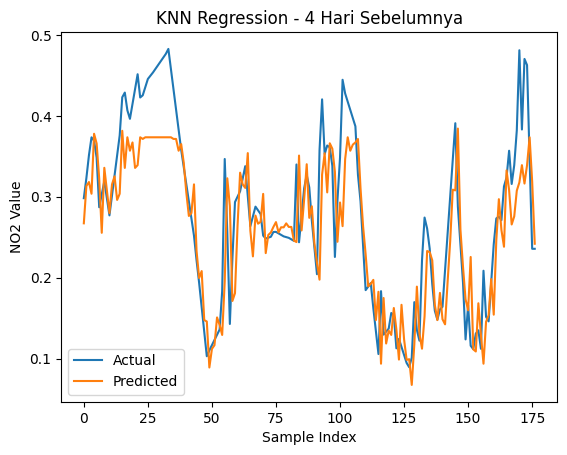

In [143]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

10 hari sebelum:

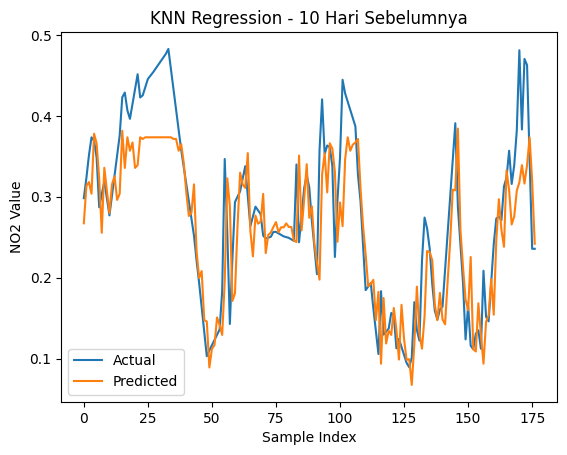

In [145]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

30 hari sebelum

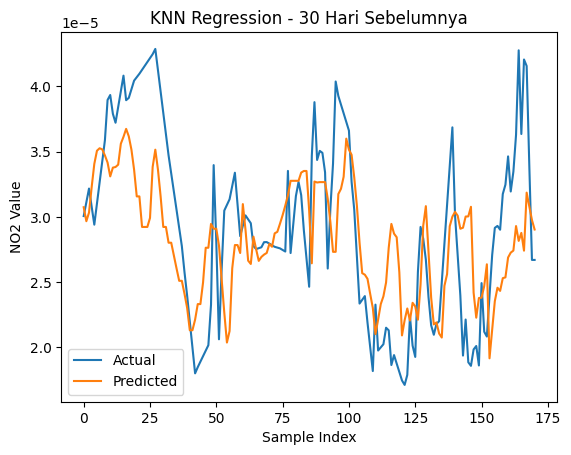

In [146]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()